<a href="https://colab.research.google.com/github/ruchira0011/Electricity-Demand-Forecasting-in-Great-Britain/blob/main/Uk_Energy_Sarimax.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing Data

In [3]:
import pandas as pd

# List of NESO Historic Demand CSV URLs (you can extend this list)
urls = {
    2026: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/8a4a771c-3929-4e56-93ad-cdf13219dea5/download/demanddata_2026.csv",
    2025: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/b2bde559-3455-4021-b179-dfe60c0337b0/download/demanddata_2025.csv",
    2024: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/f6d02c0f-957b-48cb-82ee-09003f2ba759/download/demanddata_2024.csv",
    2023: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/bf5ab335-9b40-4ea4-b93a-ab4af7bce003/download/demanddata_2023.csv",
    2022: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/bb44a1b5-75b1-4db2-8491-257f23385006/download/demanddata_2022.csv",
    2021: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/18c69c42-f20d-46f0-84e9-e279045befc6/download/demanddata_2021.csv",
    2020: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/33ba6857-2a55-479f-9308-e5c4c53d4381/download/demanddata_2020.csv",
    2019: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/dd9de980-d724-415a-b344-d8ae11321432/download/demanddata_2019.csv",
    2018: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/fcb12133-0db0-4f27-a4a5-1669fd9f6d33/download/demanddata_2018.csv",
    2017: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/2f0f75b8-39c5-46ff-a914-ae38088ed022/download/demanddata_2017.csv",
    2016: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/3bb75a28-ab44-4a0b-9b1c-9be9715d3c44/download/demanddata_2016.csv",
    2015: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/cc505e45-65ae-4819-9b90-1fbb06880293/download/demanddata_2015.csv",
    2014: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/b9005225-49d3-40d1-921c-03ee2d83a2ff/download/demanddata_2014.csv",
    2013: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/2ff7aaff-8b42-4c1b-b234-9446573a1e27/download/demanddata_2013.csv",
    2012: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/4bf713a2-ea0c-44d3-a09a-63fc6a634b00/download/demanddata_2012.csv",
    2011: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/01522076-2691-4140-bfb8-c62284752efd/download/demanddata_2011.csv",
    2010: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/b3eae4a5-8c3c-4df1-b9de-7db243ac3a09/download/demanddata_2010.csv"
}

def load_neso_demand(urls: dict) -> pd.DataFrame:
    dfs = []
    for year, url in urls.items():
        print(f"Loading {year} data...")
        df_year = pd.read_csv(url)
        df_year["Year"] = year  # optional: keep track of source year
        dfs.append(df_year)
    return pd.concat(dfs, ignore_index=True)

df = load_neso_demand(urls)

print("Shape:", df.shape)
print(df.head())
print(df.columns)

Loading 2026 data...
Loading 2025 data...
Loading 2024 data...
Loading 2023 data...
Loading 2022 data...
Loading 2021 data...
Loading 2020 data...
Loading 2019 data...
Loading 2018 data...
Loading 2017 data...
Loading 2016 data...
Loading 2015 data...
Loading 2014 data...
Loading 2013 data...
Loading 2012 data...
Loading 2011 data...
Loading 2010 data...
Shape: (284592, 24)
  SETTLEMENT_DATE  SETTLEMENT_PERIOD     ND FORECAST_ACTUAL_INDICATOR    TSD  \
0      2026-01-01                  1  25107                         A  29668   
1      2026-01-01                  2  25881                         A  30361   
2      2026-01-01                  3  25355                         A  30681   
3      2026-01-01                  4  24762                         A  30225   
4      2026-01-01                  5  24111                         A  29092   

   ENGLAND_WALES_DEMAND  EMBEDDED_WIND_GENERATION  EMBEDDED_WIND_CAPACITY  \
0                 23625                      3978                

In [4]:
df.tail()

,SETTLEMENT_DATE,SETTLEMENT_PERIOD,ND,FORECAST_ACTUAL_INDICATOR,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,...,IFA2_FLOW,BRITNED_FLOW,MOYLE_FLOW,EAST_WEST_FLOW,NEMO_FLOW,NSL_FLOW,ELECLINK_FLOW,VIKING_FLOW,GREENLINK_FLOW,Year
284587,31-DEC-2010,44,35215,NaN,36272,31765,390,2141,0,79,...,0,0,-450,0,0,NaN,NaN,NaN,NaN,2010
284588,31-DEC-2010,45,34181,NaN,35238,30811,390,2141,0,79,...,0,0,-450,0,0,NaN,NaN,NaN,NaN,2010
284589,31-DEC-2010,46,33822,NaN,34871,30399,449,2141,0,79,...,0,0,-442,0,0,NaN,NaN,NaN,NaN,2010
284590,31-DEC-2010,47,33410,NaN,34403,29831,449,2141,0,79,...,0,0,-381,0,0,NaN,NaN,NaN,NaN,2010
284591,31-DEC-2010,48,33457,NaN,34516,29843,484,2141,0,79,...,0,0,-382,0,0,NaN,NaN,NaN,NaN,2010


# Data Preprocessing

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df.drop(columns=['SCOTTISH_TRANSFER','NSL_FLOW','ELECLINK_FLOW','VIKING_FLOW',
                 'GREENLINK_FLOW', 'IFA_FLOW', 'IFA2_FLOW', 'BRITNED_FLOW',
                 'MOYLE_FLOW', 'EAST_WEST_FLOW', 'NEMO_FLOW'], inplace=True)

# 1. Convert date column to datetime
df["SETTLEMENT_DATE"] = pd.to_datetime(df["SETTLEMENT_DATE"], format='mixed',
                                       dayfirst=True)

# 2. Ensure settlement period is numeric
df["SETTLEMENT_PERIOD"] = pd.to_numeric(df["SETTLEMENT_PERIOD"])

# 3. Create full timestamp (each period = 30 minutes)
df["timestamp"] = df["SETTLEMENT_DATE"] + pd.to_timedelta(
    (df["SETTLEMENT_PERIOD"] - 1) * 30, unit="min"
)

# 4. Set timestamp as index
df = df.set_index("timestamp")

# 5. Sort by time
df = df.sort_index()

# 6. Assign demand column
demand_col = "ND"
demand = df[demand_col]

# 7. Basic dataset info
print("Data shape:", df.shape)
print("Date range:", df.index.min(), "to", df.index.max())

# 8. Demand statistics
print(demand.describe())


# missing value handling
# Missingness
missing = df.isna().mean().sort_values(ascending=False) * 100
print("Top missing % columns:")
display(missing.head(10))

# Duplicates in time index
dup_count = df.index.duplicated().sum()
print("Duplicate timestamps:", dup_count)

# If duplicates exist, aggregate them
if dup_count > 0:
    df = df.groupby(df.index).mean(numeric_only=True)
    print("After aggregating duplicates -> shape:", df.shape)


# Select demand series
series = df["ND"]
series


Data shape: (284592, 13)
Date range: 2010-01-01 00:00:00 to 2026-03-31 23:30:00
count    284592.000000
mean      30569.458281
std        7698.419276
min       12803.000000
25%       24408.000000
50%       29769.000000
75%       36142.000000
max       59095.000000
Name: ND, dtype: float64
Top missing % columns:


,0
FORECAST_ACTUAL_INDICATOR,98.566369
SETTLEMENT_DATE,0.000000
SETTLEMENT_PERIOD,0.000000
ND,0.000000
TSD,0.000000
ENGLAND_WALES_DEMAND,0.000000
EMBEDDED_WIND_GENERATION,0.000000
EMBEDDED_WIND_CAPACITY,0.000000
EMBEDDED_SOLAR_GENERATION,0.000000
EMBEDDED_SOLAR_CAPACITY,0.000000


Duplicate timestamps: 32
After aggregating duplicates -> shape: (284560, 11)


,ND
timestamp,
2010-01-01 00:00:00,36453.0
2010-01-01 00:30:00,36680.0
2010-01-01 01:00:00,36343.0
2010-01-01 01:30:00,35362.0
2010-01-01 02:00:00,34366.0
...,...
2026-03-31 21:30:00,27169.0
2026-03-31 22:00:00,25638.0
2026-03-31 22:30:00,24861.0


Final shape: (47434,)
Date range: 2010-01-01 00:00:00 to 2026-03-31 21:00:00


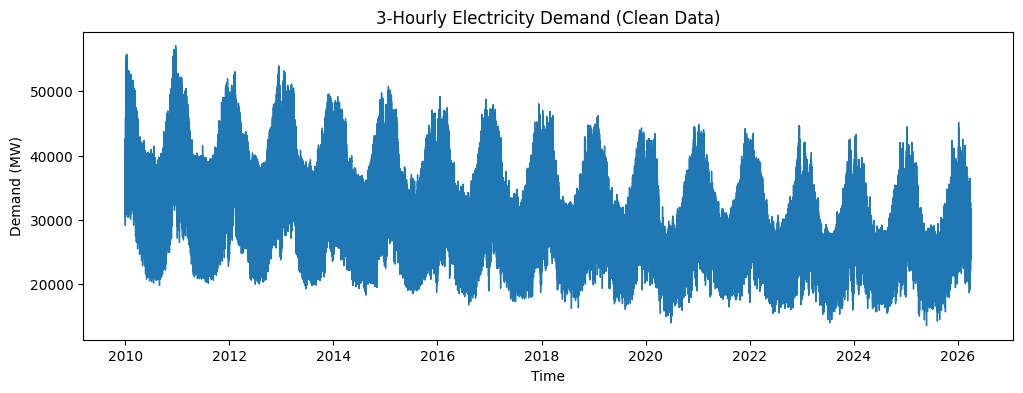

In [6]:
# -------------------------------
# 6. RESAMPLE → 4-HOURLY
# -------------------------------
series = df["ND"].resample("3h").mean().dropna()

# Remove missing after resampling
series = series.dropna()

# -------------------------------
# 7. FINAL CHECK
# -------------------------------
print("Final shape:", series.shape)
print("Date range:", series.index.min(), "to", series.index.max())

# -------------------------------
# 8. CLEAN PLOT
# -------------------------------
plt.figure(figsize=(12,4))
plt.plot(series, linewidth=1)
plt.title("3-Hourly Electricity Demand (Clean Data)")
plt.xlabel("Time")
plt.ylabel("Demand (MW)")
plt.show()

In [7]:
df.index.max()

Timestamp('2026-03-31 23:30:00')

In [8]:
df.tail()

,SETTLEMENT_PERIOD,ND,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,NON_BM_STOR,PUMP_STORAGE_PUMPING,Year
timestamp,,,,,,,,,,,
2026-03-31 21:30:00,44.0,27169.0,31221.0,24854.0,1037.0,6417.0,0.0,22126.0,0.0,9.0,2026.0
2026-03-31 22:00:00,45.0,25638.0,29690.0,23489.0,1051.0,6417.0,0.0,22126.0,0.0,9.0,2026.0
2026-03-31 22:30:00,46.0,24861.0,28983.0,22737.0,1065.0,6417.0,0.0,22126.0,0.0,9.0,2026.0
2026-03-31 23:00:00,47.0,24019.0,28762.0,21892.0,1082.0,6417.0,0.0,22126.0,0.0,9.0,2026.0
2026-03-31 23:30:00,48.0,23774.0,28403.0,21738.0,1104.0,6417.0,0.0,22126.0,0.0,9.0,2026.0


# Sarimax Model

## model fitting

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# -------------------------------
# Ensure clean series
# -------------------------------
series = series.dropna()

# Ensure correct frequency
series = series.asfreq("3h")

# -------------------------------
# Train / Test split
# -------------------------------
train = series.loc[:'2025-12-31']
test  = series.loc['2026-01-01':]

print("Train size:", len(train))
print("Test size:", len(test))

# -------------------------------
# SARIMAX MODEL
# -------------------------------
model = SARIMAX(
    train,
    order=(2,0,2),
    seasonal_order=(1,1,1,8),  # 6 = 4-hour periods per day
    enforce_stationarity=False,
    enforce_invertibility=False
)

print("Fitting model...")
model_fit = model.fit(disp=False, maxiter=50)



Train size: 46752
Test size: 720
Fitting model...


## model forcasting

SARIMAX MAE: 3231.264251035906
SARIMAX RMSE: 4148.111740117222


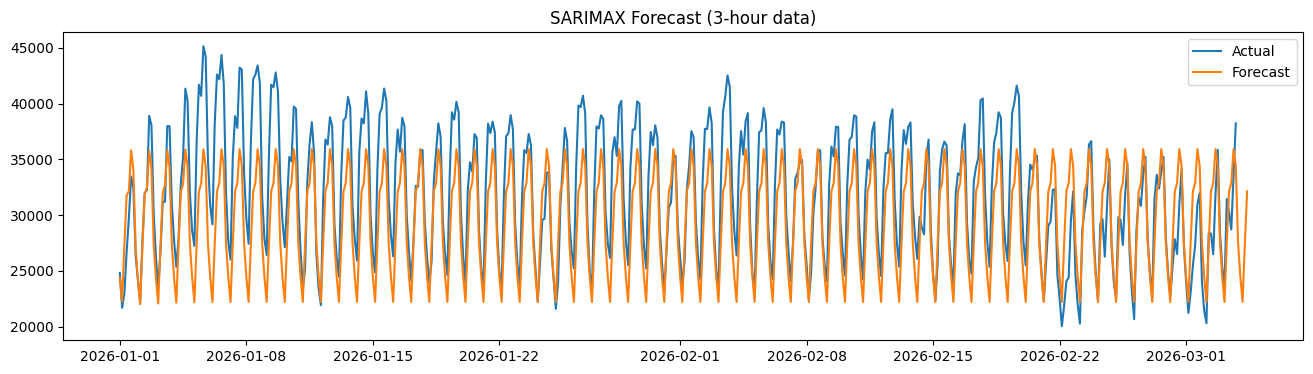

In [10]:
# -------------------------------
# Forecast
# -------------------------------
forecast = model_fit.forecast(steps=len(test))
forecast.index = test.index

# -------------------------------
# Evaluation
# -------------------------------
mae = np.mean(np.abs(test - forecast))
rmse = np.sqrt(np.mean((test - forecast)**2))

print("SARIMAX MAE:", mae)
print("SARIMAX RMSE:", rmse)

# -------------------------------
# Plot
# -------------------------------
plt.figure(figsize=(16,4))
plt.plot(test[:500], label="Actual")
plt.plot(forecast[:500], label="Forecast")
plt.legend()
plt.title("SARIMAX Forecast (3-hour data)")
plt.show()

Day MAE: 2186.0670097388834
Week MAE: 4386.00773633053


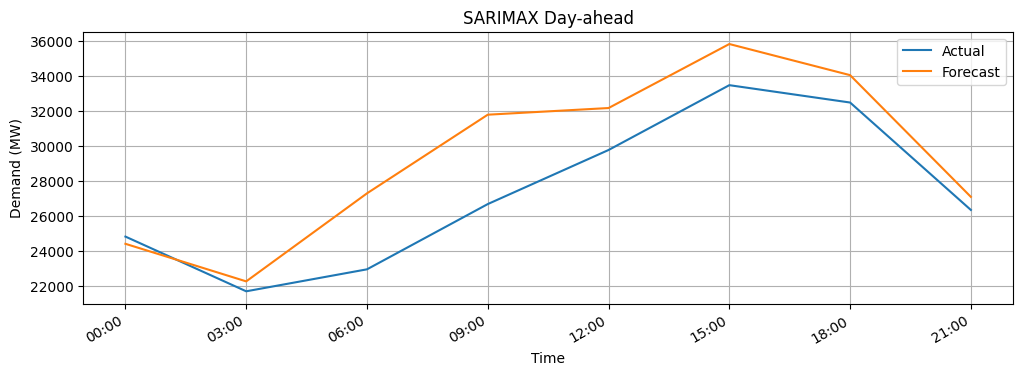

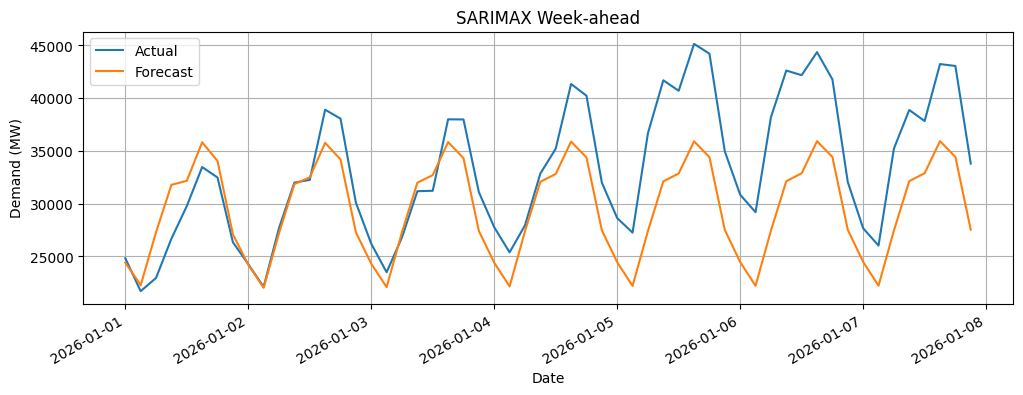

In [13]:
# -------------------------------
# Day-ahead (8 steps for 3h data)
# -------------------------------
forecast_day = model_fit.forecast(steps=8)
actual_day = test[:8]

# -------------------------------
# Week-ahead (56 steps)
# -------------------------------
forecast_week = model_fit.forecast(steps=56)
actual_week = test[:56]

# -------------------------------
# Metrics
# -------------------------------
mae_day = np.mean(np.abs(actual_day - forecast_day))
mae_week = np.mean(np.abs(actual_week - forecast_week))

print("Day MAE:", mae_day)
print("Week MAE:", mae_week)

import matplotlib.dates as mdates # Import mdates

# -------------------------------
# Plot Day
# -------------------------------
plt.figure(figsize=(12,4))
plt.plot(actual_day.index, actual_day.values, label="Actual")
plt.plot(forecast_day.index, forecast_day.values, label="Forecast")
plt.title("SARIMAX Day-ahead")
plt.xlabel("Time")
plt.ylabel("Demand (MW)")
plt.legend()
plt.grid(True)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gcf().autofmt_xdate()
plt.show()

# -------------------------------
# Plot Week
# -------------------------------
plt.figure(figsize=(12,4))
plt.plot(actual_week.index, actual_week.values, label="Actual")
plt.plot(forecast_week.index, forecast_week.values, label="Forecast")
plt.title("SARIMAX Week-ahead")
plt.xlabel("Date")
plt.ylabel("Demand (MW)")
plt.legend()
plt.grid(True)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gcf().autofmt_xdate()
plt.show()

## Hyperparameter tuning

In [ ]:
import itertools
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX

# -------------------------------
# Parameter grid (SMALL & SAFE)
# -------------------------------
p = [0, 1, 2]
d = [0, 1]
q = [0, 1, 2]

P = [0, 1]
D = [0, 1]
Q = [0, 1]

s = 8  # 3-hour data → 8 periods per day (24 / 3 = 8)

# -------------------------------
# Store best result
# -------------------------------
best_mae = float("inf")
best_order = None
best_seasonal = None

results = []

# -------------------------------
# Grid search
# -------------------------------
for order in itertools.product(p, d, q):
    for seasonal in itertools.product(P, D, Q):
        seasonal_order = (seasonal[0], seasonal[1], seasonal[2], s)

        try:
            model = SARIMAX(
                train,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            model_fit = model.fit(disp=False, maxiter=30)

            forecast = model_fit.forecast(steps=len(test))

            mae = np.mean(np.abs(test - forecast))

            results.append((order, seasonal_order, mae))

            if mae < best_mae:
                best_mae = mae
                best_order = order
                best_seasonal = seasonal_order

            print(f"Tested {order} x {seasonal_order} → MAE: {mae:.2f}")

        except:
            continue

# -------------------------------
# BEST RESULT
# -------------------------------
print("\nBEST MODEL:")
print("Order:", best_order)
print("Seasonal:", best_seasonal)
print("Best MAE:", best_mae)

Tested (0, 0, 0) x (0, 0, 0, 8) → MAE: 30577.74
Tested (0, 0, 0) x (0, 0, 1, 8) → MAE: 30439.55
Tested (0, 0, 0) x (0, 1, 0, 8) → MAE: 3235.68
Tested (0, 0, 0) x (0, 1, 1, 8) → MAE: 3199.79
Tested (0, 0, 0) x (1, 0, 0, 8) → MAE: 5250.41
Tested (0, 0, 0) x (1, 0, 1, 8) → MAE: 4893.15
Tested (0, 0, 0) x (1, 1, 0, 8) → MAE: 3224.48
Tested (0, 0, 0) x (1, 1, 1, 8) → MAE: 3187.38
Tested (0, 0, 1) x (0, 0, 0, 8) → MAE: 30560.89
Tested (0, 0, 1) x (0, 0, 1, 8) → MAE: 30405.82
Tested (0, 0, 1) x (0, 1, 0, 8) → MAE: 3207.78
Tested (0, 0, 1) x (0, 1, 1, 8) → MAE: 3316.98
Tested (0, 0, 1) x (1, 0, 0, 8) → MAE: 6743.58


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Tested (0, 0, 1) x (1, 0, 1, 8) → MAE: 286341023045007114240.00
Tested (0, 0, 1) x (1, 1, 0, 8) → MAE: 3240.60


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Tested (0, 0, 1) x (1, 1, 1, 8) → MAE: 3413.07
Tested (0, 0, 2) x (0, 0, 0, 8) → MAE: 30530.47


...

Tested (2, 1, 1) x (1, 0, 0, 8) → MAE: 4900.80


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Tested (2, 1, 1) x (1, 0, 1, 8) → MAE: 3242.67
Tested (2, 1, 1) x (1, 1, 0, 8) → MAE: 80854.23


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Tested (2, 1, 1) x (1, 1, 1, 8) → MAE: 8526.73
Tested (2, 1, 2) x (0, 0, 0, 8) → MAE: 4937.91


In [15]:
print("\nBEST MODEL:")
print("Order:", best_order)
print("Seasonal:", best_seasonal)
print("Best MAE:", best_mae)


BEST MODEL:
Order: (0, 0, 2)
Seasonal: (0, 1, 1, 8)
Best MAE: 3114.138227266818
